In [25]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [28]:
image_path = '/kaggle/input/datasets/nagagopalchimata/sample/Sample_CV.webp'

In [29]:
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

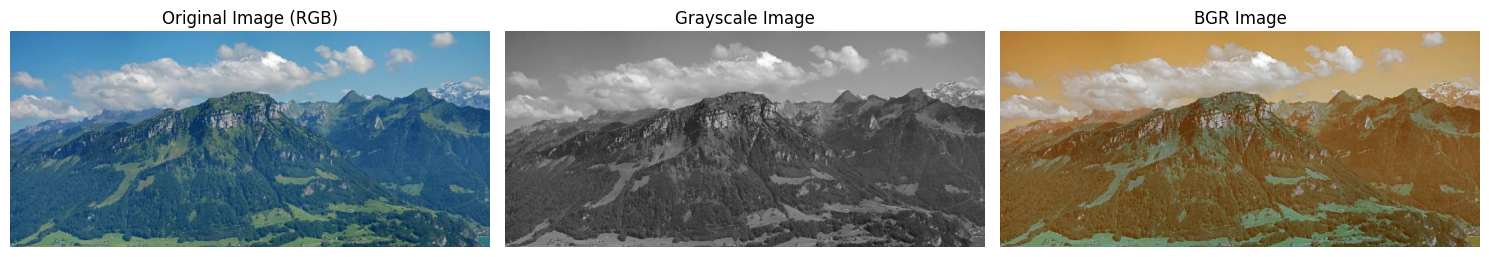

In [30]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.title("BGR Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/gatto"

import os
sample_image = os.path.join(image_path, os.listdir(image_path)[0])
print(f"Using image: {sample_image}")

Using image: /kaggle/input/datasets/alessiocorrado99/animals10/raw-img/gatto/1765.jpeg


In [32]:
img_bgr = cv2.imread(sample_image)

print(f"Shape:     {img_bgr.shape}")
print(f"Height:    {img_bgr.shape[0]}")
print(f"Width:     {img_bgr.shape[1]}")
print(f"Channels:  {img_bgr.shape[2]}")
print(f"Dtype:     {img_bgr.dtype}")
print(f"Min pixel: {img_bgr.min()}")
print(f"Max pixel: {img_bgr.max()}")

Shape:     (200, 300, 3)
Height:    200
Width:     300
Channels:  3
Dtype:     uint8
Min pixel: 0
Max pixel: 246


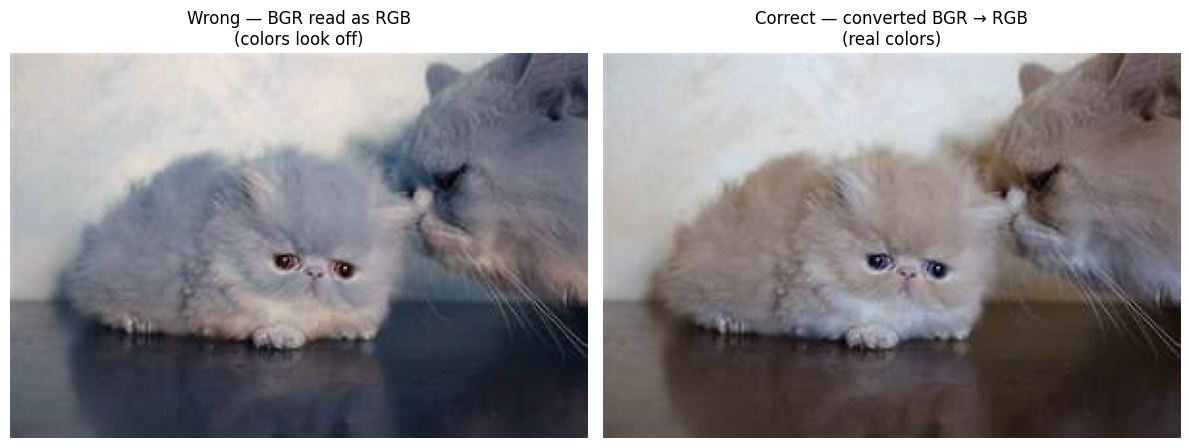

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_bgr)
axes[0].set_title("Wrong — BGR read as RGB\n(colors look off)")
axes[0].axis("off")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

axes[1].imshow(img_rgb)
axes[1].set_title("Correct — converted BGR → RGB\n(real colors)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Color image shape:     (200, 300, 3)
Grayscale image shape: (200, 300)


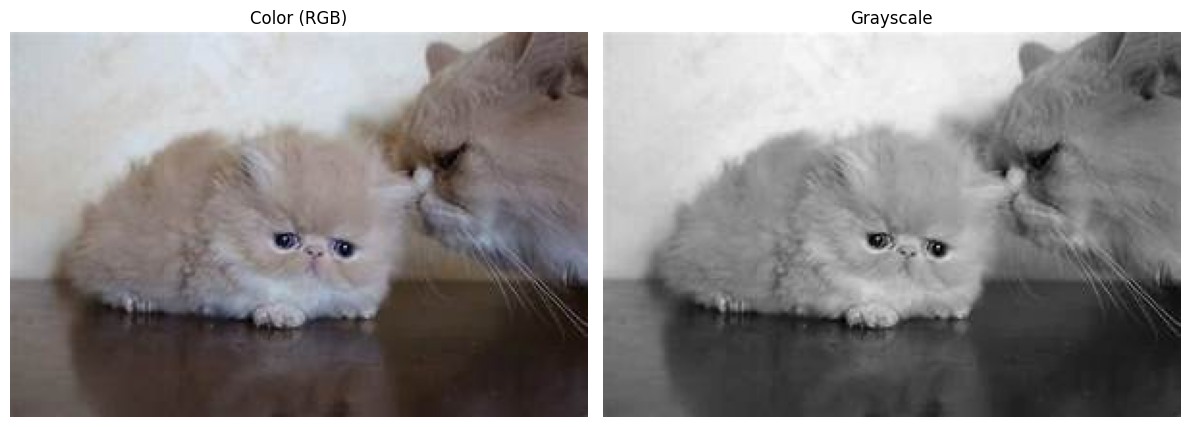

In [34]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Color image shape:     {img_bgr.shape}")
print(f"Grayscale image shape: {img_gray.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Color (RGB)")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Original: 200×300
Small:    100×100
Medium:   224×224
Large:    512×512


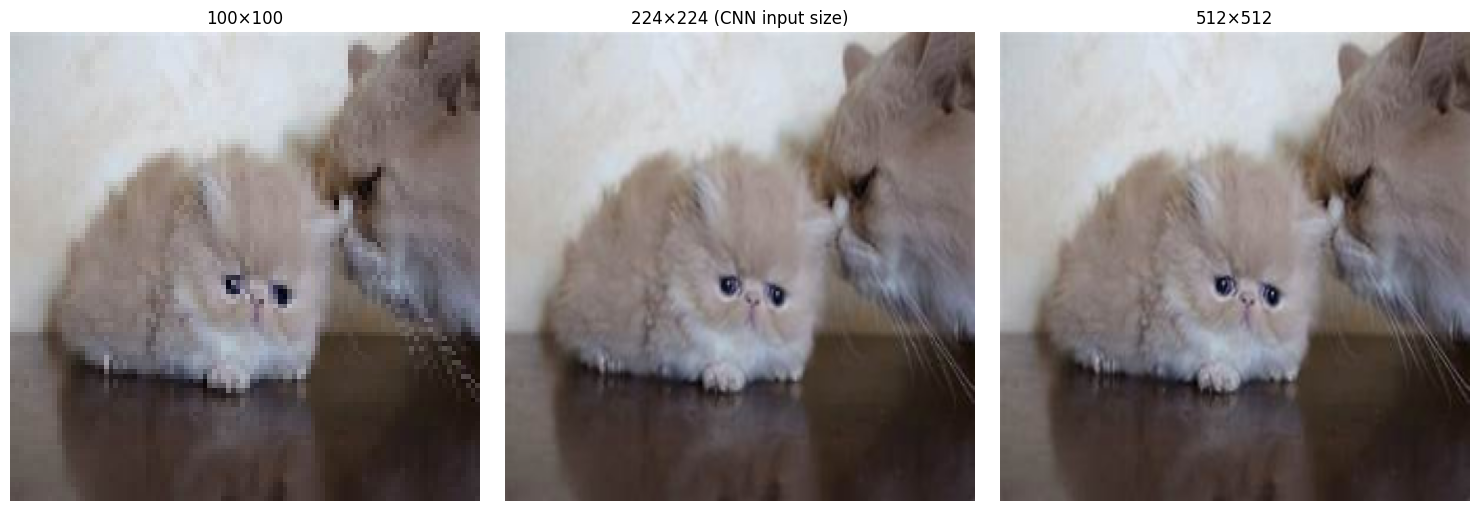

In [35]:
original_h, original_w = img_rgb.shape[:2]

img_small  = cv2.resize(img_bgr, (100, 100))
img_medium = cv2.resize(img_bgr, (224, 224))
img_large  = cv2.resize(img_bgr, (512, 512))

print(f"Original: {original_h}×{original_w}")
print(f"Small:    {img_small.shape[0]}×{img_small.shape[1]}")
print(f"Medium:   {img_medium.shape[0]}×{img_medium.shape[1]}")
print(f"Large:    {img_large.shape[0]}×{img_large.shape[1]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
axes[0].set_title("100×100")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_medium, cv2.COLOR_BGR2RGB))
axes[1].set_title("224×224 (CNN input size)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_large, cv2.COLOR_BGR2RGB))
axes[2].set_title("512×512")
axes[2].axis("off")

plt.tight_layout()
plt.show()

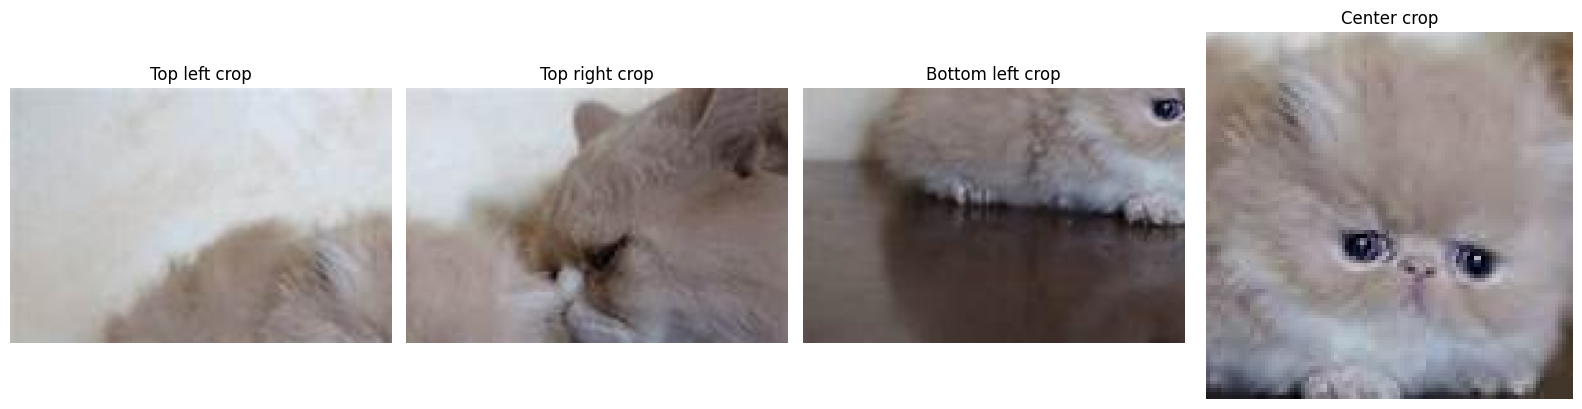

In [36]:
h, w = img_rgb.shape[:2]

center_y, center_x = h // 2, w // 2
crop_size = min(h, w) // 2

top_left     = img_rgb[0:h//2,          0:w//2         ]
top_right    = img_rgb[0:h//2,          w//2:w         ]
bottom_left  = img_rgb[h//2:h,          0:w//2         ]
center_crop  = img_rgb[center_y-crop_size//2:center_y+crop_size//2,
                       center_x-crop_size//2:center_x+crop_size//2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(top_left)
axes[0].set_title("Top left crop")
axes[0].axis("off")

axes[1].imshow(top_right)
axes[1].set_title("Top right crop")
axes[1].axis("off")

axes[2].imshow(bottom_left)
axes[2].set_title("Bottom left crop")
axes[2].axis("off")

axes[3].imshow(center_crop)
axes[3].set_title("Center crop")
axes[3].axis("off")

plt.tight_layout()
plt.show()

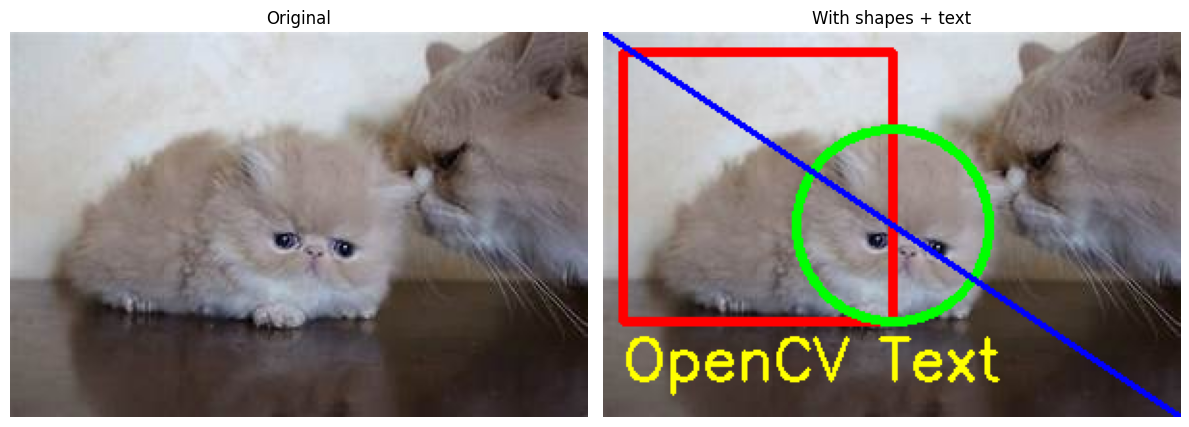

In [37]:
canvas = img_rgb.copy()

cv2.rectangle(canvas,
              pt1=(10, 10),
              pt2=(150, 150),
              color=(255, 0, 0),
              thickness=3)

cv2.circle(canvas,
           center=(canvas.shape[1]//2, canvas.shape[0]//2),
           radius=50,
           color=(0, 255, 0),
           thickness=3)

cv2.line(canvas,
         pt1=(0, 0),
         pt2=(canvas.shape[1], canvas.shape[0]),
         color=(0, 0, 255),
         thickness=2)

cv2.putText(canvas,
            text="OpenCV Text",
            org=(10, canvas.shape[0]-20),
            fontFace=cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=1,
            color=(255, 255, 0),
            thickness=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(canvas)
axes[1].set_title("With shapes + text")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [38]:
img_to_save = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

cv2.imwrite("/kaggle/working/saved_image.jpg", img_to_save)
cv2.imwrite("/kaggle/working/saved_image.png", img_to_save)

jpg_size = os.path.getsize("/kaggle/working/saved_image.jpg")
png_size = os.path.getsize("/kaggle/working/saved_image.png")

print(f"JPG size: {jpg_size/1024:.1f} KB  (compressed, loses quality)")
print(f"PNG size: {png_size/1024:.1f} KB  (lossless, keeps quality)")

JPG size: 12.3 KB  (compressed, loses quality)
PNG size: 78.5 KB  (lossless, keeps quality)


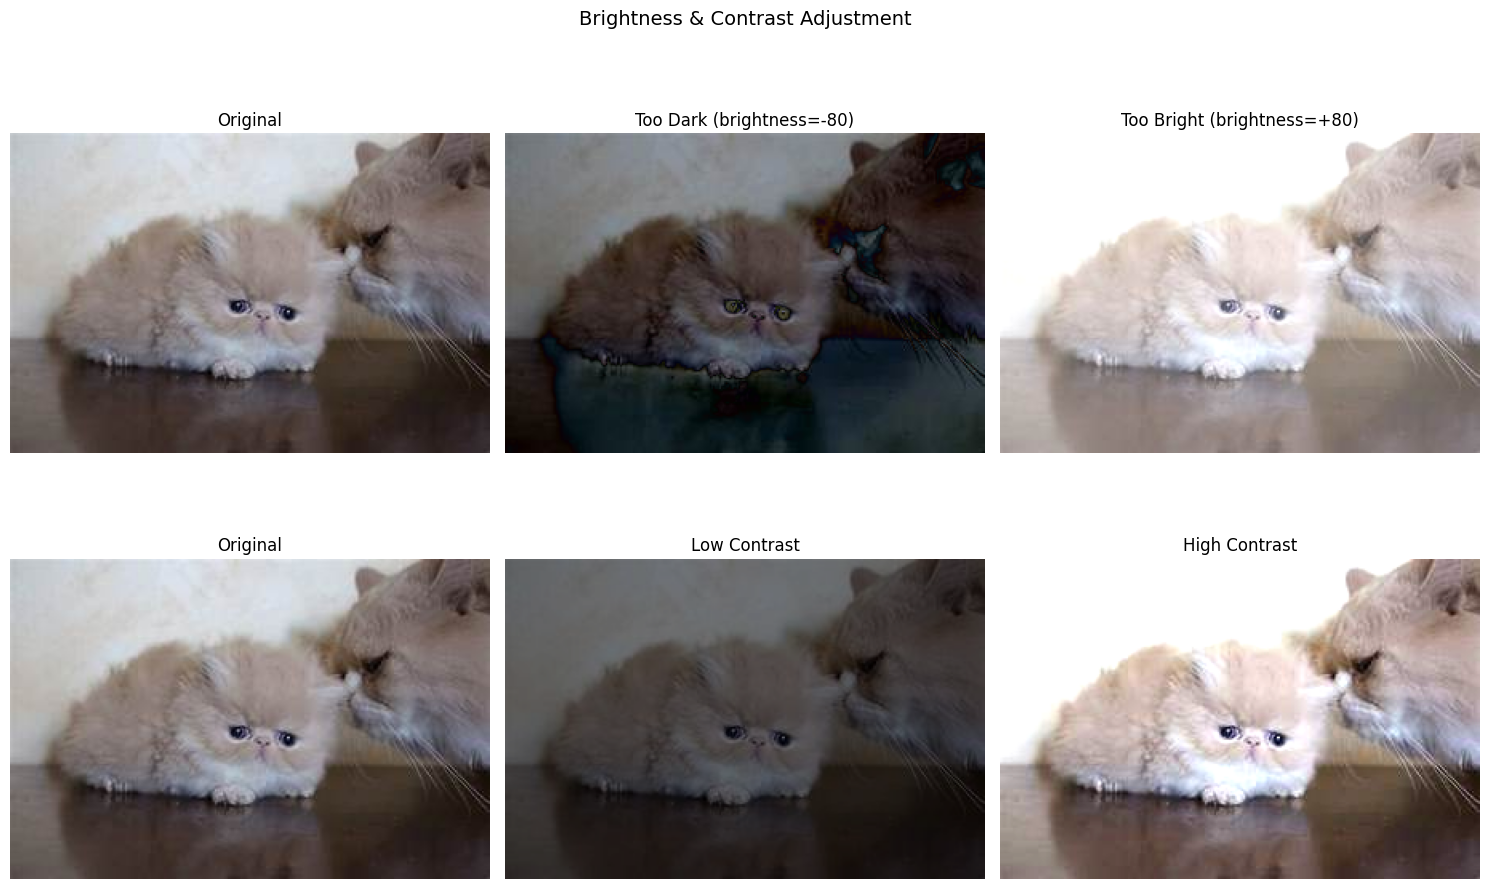

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/gatto"
sample_image = os.path.join(image_path, os.listdir(image_path)[0])

img_bgr = cv2.imread(sample_image)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def adjust_brightness_contrast(image, brightness=0, contrast=0):
    beta = brightness
    alpha = 1 + (contrast / 100.0)
    adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted

too_dark    = adjust_brightness_contrast(img_rgb, brightness=-80)
too_bright  = adjust_brightness_contrast(img_rgb, brightness=80)
low_contrast = adjust_brightness_contrast(img_rgb, contrast=-50)
high_contrast = adjust_brightness_contrast(img_rgb, contrast=50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Original")
axes[0,0].axis("off")

axes[0,1].imshow(too_dark)
axes[0,1].set_title("Too Dark (brightness=-80)")
axes[0,1].axis("off")

axes[0,2].imshow(too_bright)
axes[0,2].set_title("Too Bright (brightness=+80)")
axes[0,2].axis("off")

axes[1,0].imshow(img_rgb)
axes[1,0].set_title("Original")
axes[1,0].axis("off")

axes[1,1].imshow(low_contrast)
axes[1,1].set_title("Low Contrast")
axes[1,1].axis("off")

axes[1,2].imshow(high_contrast)
axes[1,2].set_title("High Contrast")
axes[1,2].axis("off")

plt.suptitle("Brightness & Contrast Adjustment", fontsize=14)
plt.tight_layout()
plt.show()

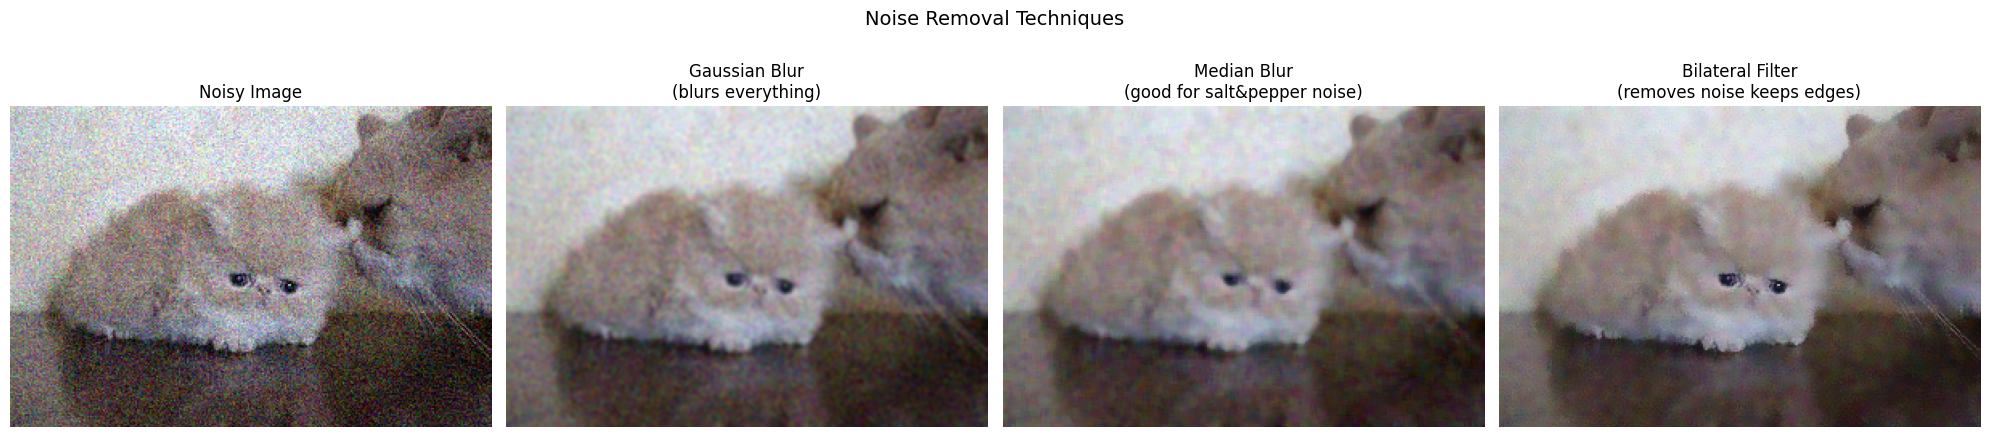

In [40]:
noisy = img_rgb.copy().astype(np.float32)
noise = np.random.normal(0, 25, img_rgb.shape)
noisy = np.clip(noisy + noise, 0, 255).astype(np.uint8)

gaussian_blur    = cv2.GaussianBlur(noisy, (5, 5), 0)
median_blur      = cv2.medianBlur(noisy, 5)
bilateral_filter = cv2.bilateralFilter(noisy, 9, 75, 75)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(noisy)
axes[0].set_title("Noisy Image")
axes[0].axis("off")

axes[1].imshow(gaussian_blur)
axes[1].set_title("Gaussian Blur\n(blurs everything)")
axes[1].axis("off")

axes[2].imshow(median_blur)
axes[2].set_title("Median Blur\n(good for salt&pepper noise)")
axes[2].axis("off")

axes[3].imshow(bilateral_filter)
axes[3].set_title("Bilateral Filter\n(removes noise keeps edges)")
axes[3].axis("off")

plt.suptitle("Noise Removal Techniques", fontsize=14)
plt.tight_layout()
plt.show()

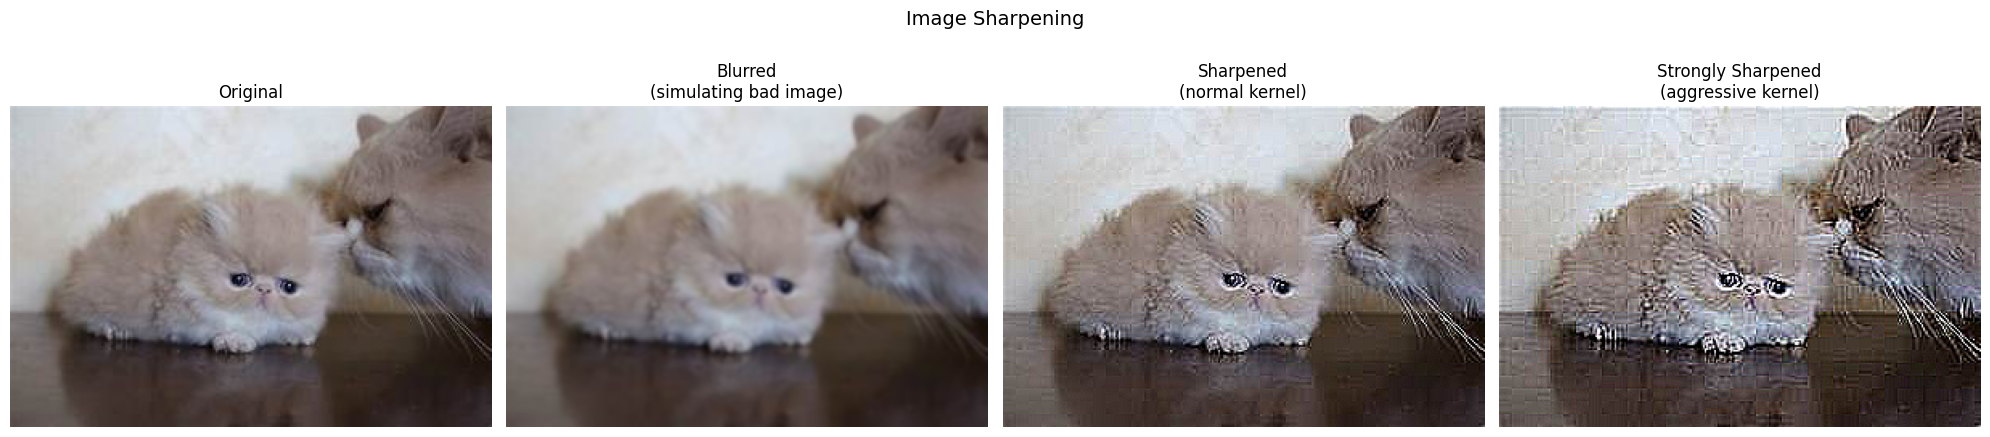

In [41]:
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

kernel_sharpen_strong = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])

img_bgr_blur   = cv2.GaussianBlur(img_bgr, (5, 5), 0)
img_sharp      = cv2.filter2D(img_bgr, -1, kernel_sharpen)
img_sharp_strong = cv2.filter2D(img_bgr, -1, kernel_sharpen_strong)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_bgr_blur, cv2.COLOR_BGR2RGB))
axes[1].set_title("Blurred\n(simulating bad image)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_sharp, cv2.COLOR_BGR2RGB))
axes[2].set_title("Sharpened\n(normal kernel)")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(img_sharp_strong, cv2.COLOR_BGR2RGB))
axes[3].set_title("Strongly Sharpened\n(aggressive kernel)")
axes[3].axis("off")

plt.suptitle("Image Sharpening", fontsize=14)
plt.tight_layout()
plt.show()

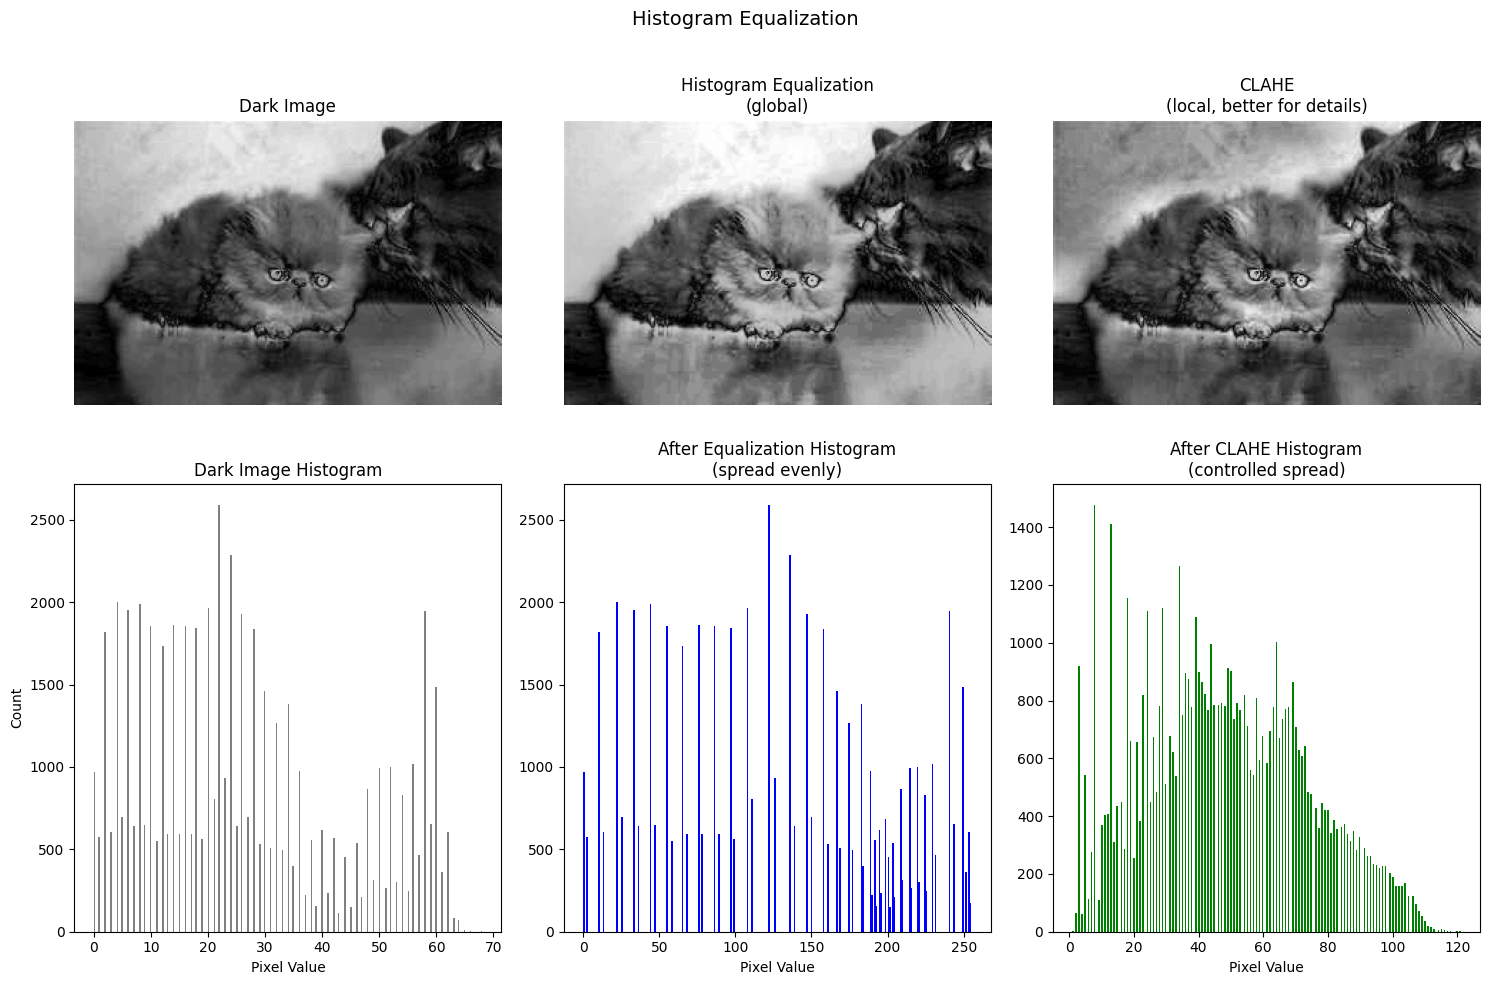

In [42]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

dark_image = cv2.convertScaleAbs(img_gray, alpha=0.5, beta=-50)

equalized      = cv2.equalizeHist(dark_image)
clahe          = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_result   = clahe.apply(dark_image)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(dark_image, cmap="gray")
axes[0,0].set_title("Dark Image")
axes[0,0].axis("off")

axes[0,1].imshow(equalized, cmap="gray")
axes[0,1].set_title("Histogram Equalization\n(global)")
axes[0,1].axis("off")

axes[0,2].imshow(clahe_result, cmap="gray")
axes[0,2].set_title("CLAHE\n(local, better for details)")
axes[0,2].axis("off")

axes[1,0].hist(dark_image.ravel(), bins=256, color="gray")
axes[1,0].set_title("Dark Image Histogram")
axes[1,0].set_xlabel("Pixel Value")
axes[1,0].set_ylabel("Count")

axes[1,1].hist(equalized.ravel(), bins=256, color="blue")
axes[1,1].set_title("After Equalization Histogram\n(spread evenly)")
axes[1,1].set_xlabel("Pixel Value")

axes[1,2].hist(clahe_result.ravel(), bins=256, color="green")
axes[1,2].set_title("After CLAHE Histogram\n(controlled spread)")
axes[1,2].set_xlabel("Pixel Value")

plt.suptitle("Histogram Equalization", fontsize=14)
plt.tight_layout()
plt.show()

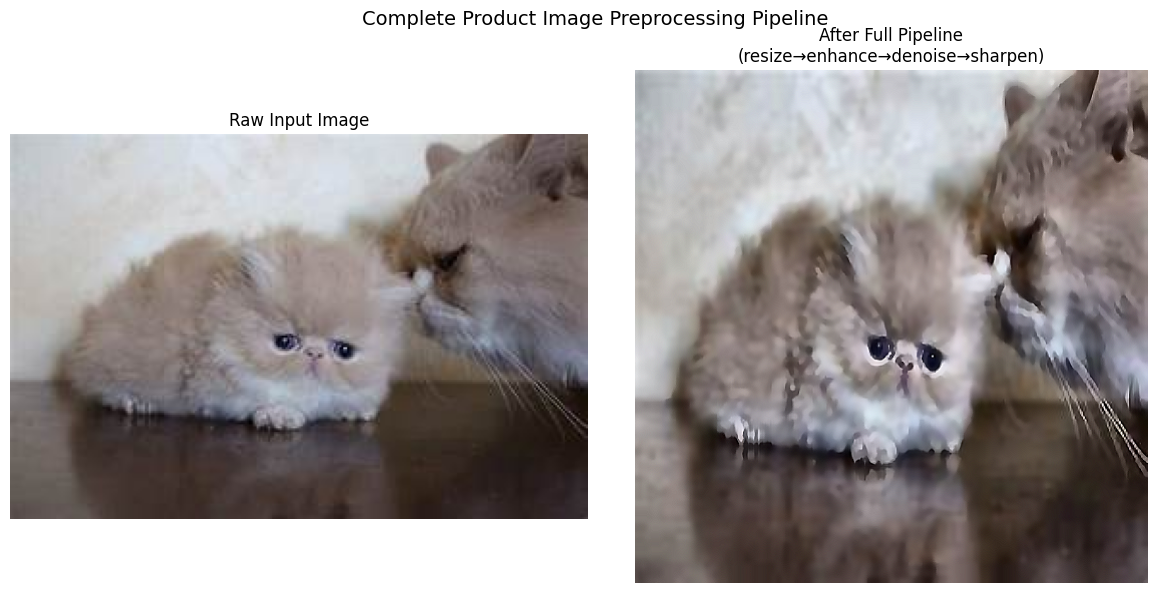

Pipeline steps completed:
  1. Resize      → 512×512 standard size
  2. CLAHE       → enhance contrast locally
  3. Bilateral   → remove noise, keep edges
  4. Sharpen     → enhance product details


In [43]:
def preprocess_product_image(image_path, target_size=(512, 512)):

    img = cv2.imread(image_path)

    img = cv2.resize(img, target_size)

    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    img = cv2.merge([l, a, b])
    img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    img = cv2.bilateralFilter(img, 9, 75, 75)

    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

original = cv2.cvtColor(cv2.imread(sample_image), cv2.COLOR_BGR2RGB)
processed = preprocess_product_image(sample_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Raw Input Image")
axes[0].axis("off")

axes[1].imshow(processed)
axes[1].set_title("After Full Pipeline\n(resize→enhance→denoise→sharpen)")
axes[1].axis("off")

plt.suptitle("Complete Product Image Preprocessing Pipeline", fontsize=14)
plt.tight_layout()
plt.show()

print("Pipeline steps completed:")
print("  1. Resize      → 512×512 standard size")
print("  2. CLAHE       → enhance contrast locally")
print("  3. Bilateral   → remove noise, keep edges")
print("  4. Sharpen     → enhance product details")

In [7]:
!pip install "numpy<2.0" -q
!pip install rembg onnxruntime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
rembg 2.0.84 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.67.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 wh

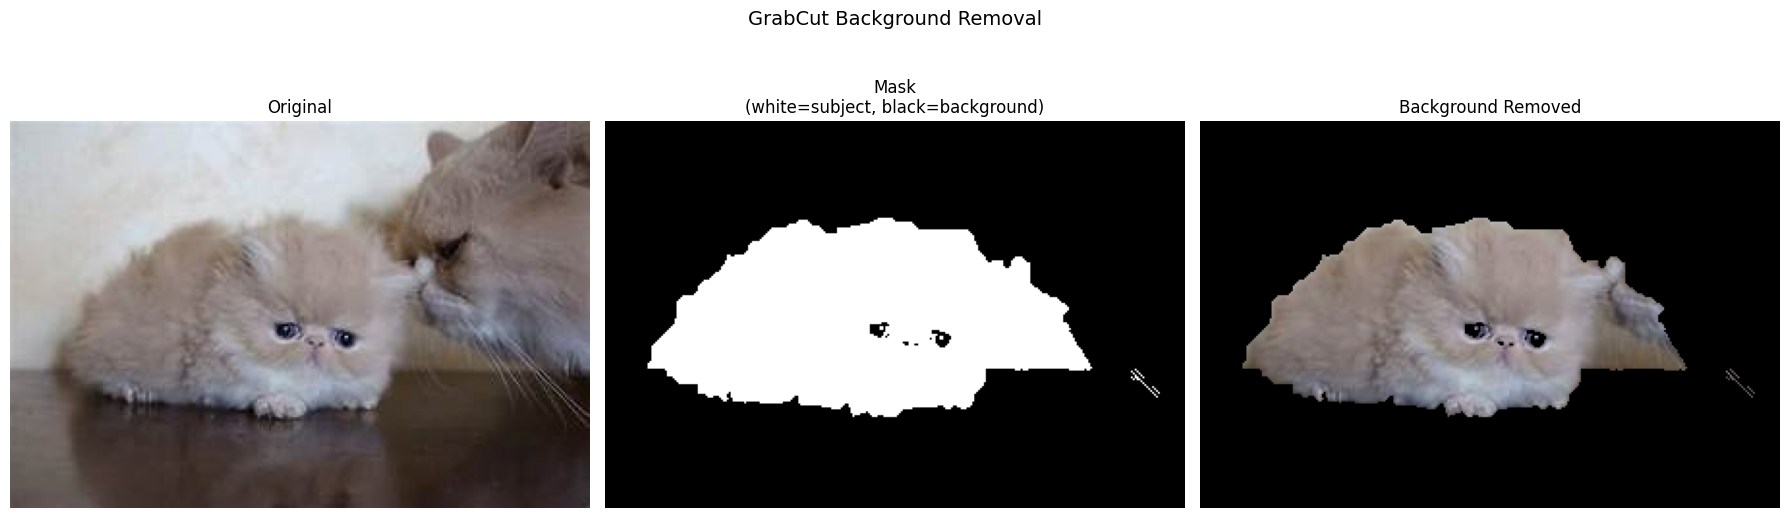

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/gatto"
sample_image = os.path.join(image_path, os.listdir(image_path)[0])

img_bgr = cv2.imread(sample_image)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_bgr.shape[:2]

mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
rect = (10, 10, w-20, h-20)

cv2.grabCut(img_bgr, mask, rect,
            bgd_model, fgd_model,
            10, cv2.GC_INIT_WITH_RECT)

final_mask = np.where(
    (mask == 2) | (mask == 0), 0, 1
).astype("uint8")

result = img_rgb * final_mask[:, :, np.newaxis]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(final_mask, cmap="gray")
axes[1].set_title("Mask\n(white=subject, black=background)")
axes[1].axis("off")

axes[2].imshow(result)
axes[2].set_title("Background Removed")
axes[2].axis("off")

plt.suptitle("GrabCut Background Removal", fontsize=14)
plt.tight_layout()
plt.show()

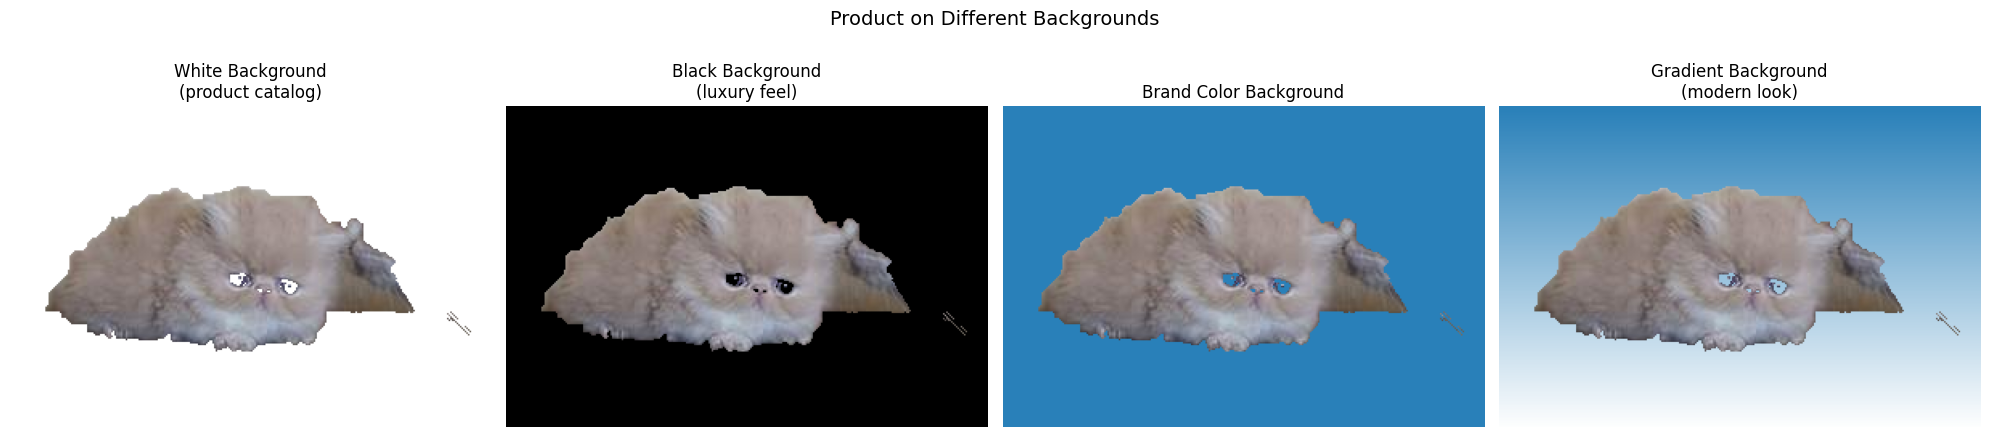

In [10]:
def place_on_background(subject, mask, bg_color):
    background = np.full_like(subject, bg_color)
    alpha = mask[:, :, np.newaxis]
    result = subject * alpha + background * (1 - alpha)
    return result.astype(np.uint8)

white_result    = place_on_background(img_rgb, final_mask, 255)
black_result    = place_on_background(img_rgb, final_mask, 0)

brand_bg = np.full_like(img_rgb, [41, 128, 185])
brand_result = place_on_background(img_rgb, final_mask, 0)
brand_result = img_rgb * final_mask[:, :, np.newaxis] + \
               brand_bg * (1 - final_mask[:, :, np.newaxis])
brand_result = brand_result.astype(np.uint8)

gradient_bg = np.zeros_like(img_rgb)
for i in range(h):
    ratio = i / h
    gradient_bg[i, :] = [
        int(41  + (255 - 41)  * ratio),
        int(128 + (255 - 128) * ratio),
        int(185 + (255 - 185) * ratio)
    ]
gradient_result = (img_rgb * final_mask[:, :, np.newaxis] +
                   gradient_bg * (1 - final_mask[:, :, np.newaxis])
                   ).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(white_result)
axes[0].set_title("White Background\n(product catalog)")
axes[0].axis("off")

axes[1].imshow(black_result)
axes[1].set_title("Black Background\n(luxury feel)")
axes[1].axis("off")

axes[2].imshow(brand_result)
axes[2].set_title("Brand Color Background")
axes[2].axis("off")

axes[3].imshow(gradient_result)
axes[3].set_title("Gradient Background\n(modern look)")
axes[3].axis("off")

plt.suptitle("Product on Different Backgrounds", fontsize=14)
plt.tight_layout()
plt.show()

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7037.7/8062.4 GB disk)
